# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve.


### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 86.7 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'  # TODO: choose a causal LM checkpoint, e.g., 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)   # TODO: load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # TODO: load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


Original Text: Hello, how are you today?
Tokens: ['Hello', ',', 'Ġhow', 'Ġare', 'Ġyou', 'Ġtoday', '?']
Token IDs: [15496, 11, 703, 389, 345, 1909, 30]


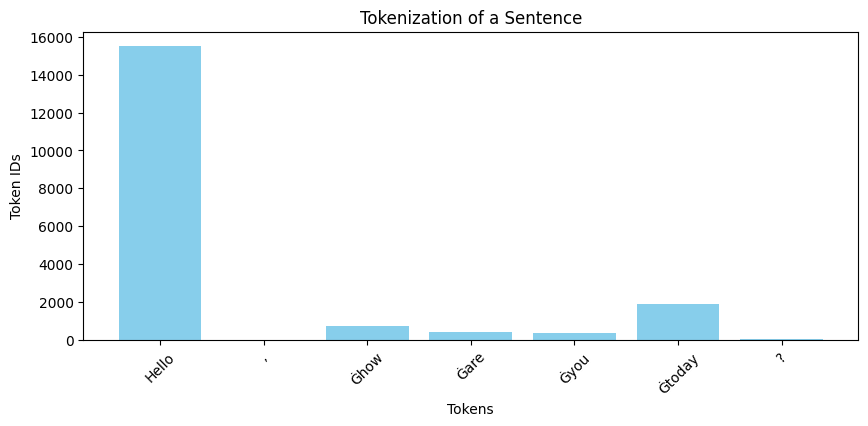

In [5]:
text = "Hello, how are you today?"  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Tokenization of a Sentence"    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

 Exercise 3 · Token IDs and special prefixes


In [7]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
print("\nToken to ID mapping:")
for token, token_id in zip(tokens, token_ids):
    print(f"Token: '{token}' -> ID: {token_id}")


Token to ID mapping:
Token: 'Hello' -> ID: 15496
Token: ',' -> ID: 11
Token: 'Ġhow' -> ID: 703
Token: 'Ġare' -> ID: 389
Token: 'Ġyou' -> ID: 345
Token: 'Ġtoday' -> ID: 1909
Token: '?' -> ID: 30


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.


 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [9]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The quick brown fox jumped over the lazy dog."  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: The quick brown fox jumped over the lazy dog.
Generated Output: The quick brown fox jumped over the lazy dog.

"Uh, hello?" the fox said. "What's up?"

"You were kind of a mess this morning," the fox said, "but I'm here today for a little lesson."

"Uh huh." the fox said, "Just let me have my fun


In [10]:
input_text = "Once upon a time, in a land far away, there was a dragon named Smaug." # New prompt for Exercise 5

output_ids = generator(input_text, **gen_kwargs)  # Generate output with the new prompt
output_text = output_ids[0]["generated_text"]     # Extract the generated text

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input: Once upon a time, in a land far away, there was a dragon named Smaug.
Generated Output: Once upon a time, in a land far away, there was a dragon named Smaug. The dragons were among the most ferocious creatures the known world had ever known. It was said that the dragon was said to be the "father of all magic," but it was only after the dragon was dead that the world was finally brought to life.

The first time Smaug killed the dragon


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)